1. Read and display the image.
• Read the image using the Pillow library and display it.
• You can also use matplotlib to display the image.

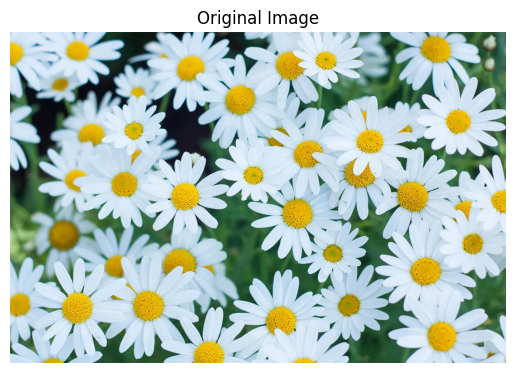

In [2]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# Read image
img = Image.open("/content/drive/MyDrive/AI and ML/Data/Shasta-daisies.webp")

# Display image
plt.imshow(img)
plt.axis("off")
plt.title("Original Image")
plt.show()

2. Display only the top left corner of 100x100 pixels.
• Extract the top-left corner of the image (100x100 pixels) and display it using NumPy and
Array Indexing.

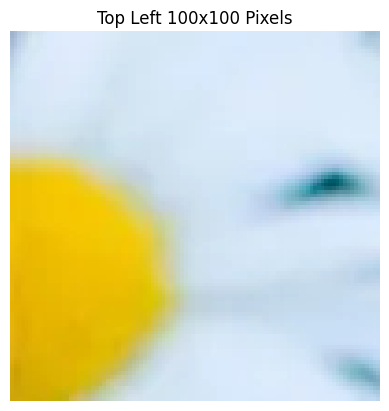

In [3]:
# Convert image to numpy array
img_array = np.array(img)

# Extract top-left 100x100 pixels
top_left = img_array[0:100, 0:100]

# Display cropped region
plt.imshow(top_left)
plt.axis("off")
plt.title("Top Left 100x100 Pixels")
plt.show()

3. Show the three color channels (R, G, B).
• Separate the image into its three color channels (Red, Green, and Blue) and display them
individually, labeling each channel as R, G, and B.{Using NumPy.}

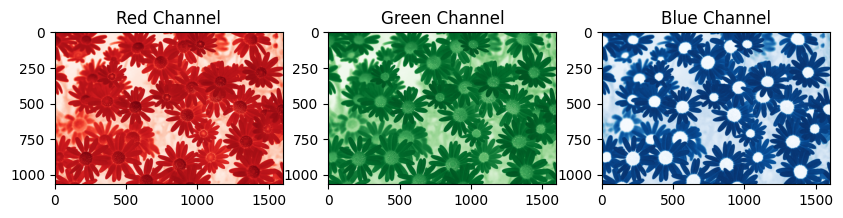

In [4]:
# Separate color channels
R = img_array[:, :, 0]
G = img_array[:, :, 1]
B = img_array[:, :, 2]

# Display channels
plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.imshow(R, cmap="Reds")
plt.title("Red Channel")

plt.subplot(1,3,2)
plt.imshow(G, cmap="Greens")
plt.title("Green Channel")

plt.subplot(1,3,3)
plt.imshow(B, cmap="Blues")
plt.title("Blue Channel")

plt.show()

4. Modify the top 100 × 100 pixels to a value of 210 and display the resulting image:
• Modify the pixel values of the top-left 100 × 100 region to have a value of 210 (which is a
light gray color), and then display the modified image.

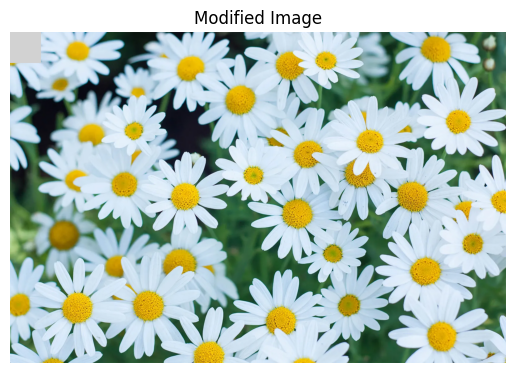

In [5]:
# Modify top-left region
img_array[0:100, 0:100] = 210

# Display modified image
plt.imshow(img_array)
plt.axis("off")
plt.title("Modified Image")
plt.show()

2.2 Exercise - 2:
Complete all the Task.
1. Load and display a grayscale image.
• Load a grayscale image using the Pillow library.
• Display the grayscale image using matplotlib.

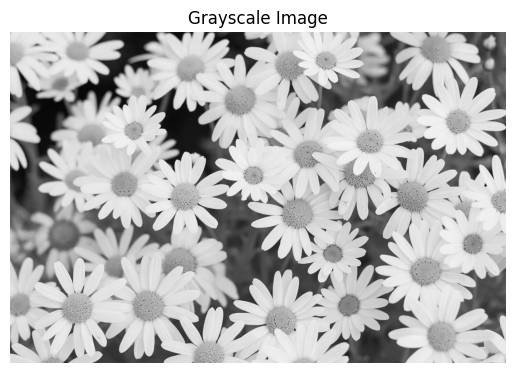

In [6]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Load grayscale image
img = Image.open("/content/drive/MyDrive/AI and ML/Data/Shasta-daisies.webp").convert("L")

# Display image
plt.imshow(img, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

2. Extract and display the middle section of the image (150 pixels).
• Extract a 150 pixel section from the center of the image using NumPy array slicing.
• Display this cropped image using matplotlib.

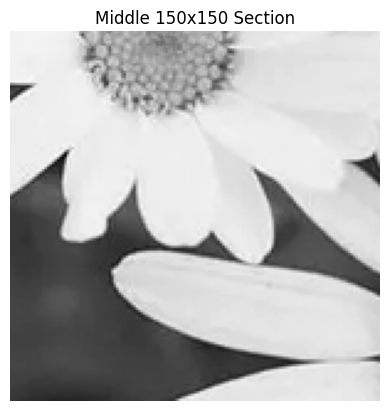

In [7]:
img_array = np.array(img)

h, w = img_array.shape

# Center coordinates
center_h = h // 2
center_w = w // 2

# Crop 150x150 center
middle = img_array[center_h-75:center_h+75, center_w-75:center_w+75]

plt.imshow(middle, cmap="gray")
plt.title("Middle 150x150 Section")
plt.axis("off")
plt.show()

3. Apply a simple threshold to the image (e.g., set all pixel values below 100 to 0).
• Apply a threshold to the grayscale image: set all pixel values below 100 to 0, and all values
above 100 to 255 (creating a binary image).
• Display the resulting binary image.

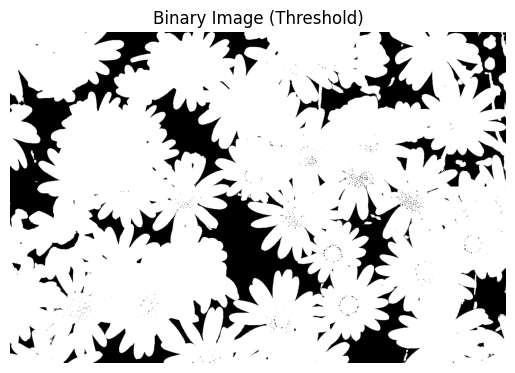

In [8]:
binary = img_array.copy()

binary[binary < 100] = 0
binary[binary >= 100] = 255

plt.imshow(binary, cmap="gray")
plt.title("Binary Image (Threshold)")
plt.axis("off")
plt.show()

4. Rotate the image 90 degrees clockwise and display the result.
• Rotate the image by 90 degrees clockwise using the Pillow rotate method or by manipulating
the image array.
• Display the rotated image using matplotlib.

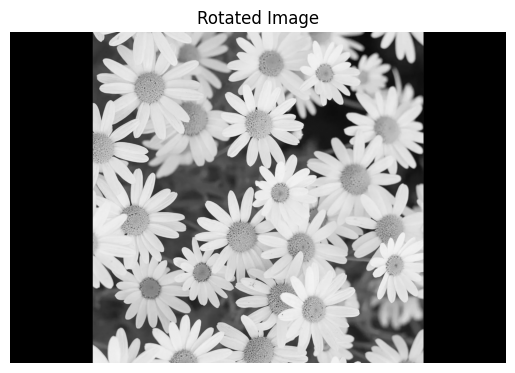

In [9]:
rotated = img.rotate(-90)

plt.imshow(rotated, cmap="gray")
plt.title("Rotated Image")
plt.axis("off")
plt.show()

5. Convert the grayscale image to an RGB image.
• Convert the grayscale image into an RGB image where the grayscale values are replicated
across all three channels (R, G, and B).
• Display the converted RGB image using matplotlib.

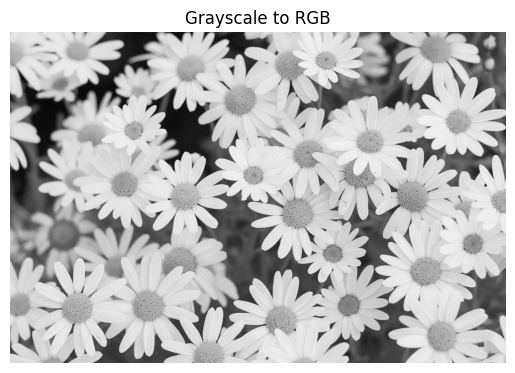

In [10]:
rgb = np.stack((img_array,)*3, axis=-1)

plt.imshow(rgb)
plt.title("Grayscale to RGB")
plt.axis("off")
plt.show()

1. Load and Prepare Data:
• Fetch an image of you choice.{If colour convert to grayscale}
• Center the dataset - Standaridze the Data.
• Calculate the covaraince matrix of the Standaridze data.

In [11]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

img = Image.open("/content/drive/MyDrive/AI and ML/Data/Shasta-daisies.webp").convert("L")
img_array = np.array(img)

In [12]:
mean = np.mean(img_array, axis=0)
centered_data = img_array - mean

In [13]:
cov_matrix = np.cov(centered_data, rowvar=False)

2. Eigen Decomposition and Identifying Principal Components:
• Compute Eigen Values and Eigen Vectors.
• Sort the eigenvalues in descending order and choose the top k eigenvectors corresponding to
the highest eigenvalues.
• Identify the Principal Components with the help of cumulative Sum plot.

In [14]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

In [17]:
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# sort descending
idx = np.argsort(eigenvalues)[::-1]

eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:,idx]

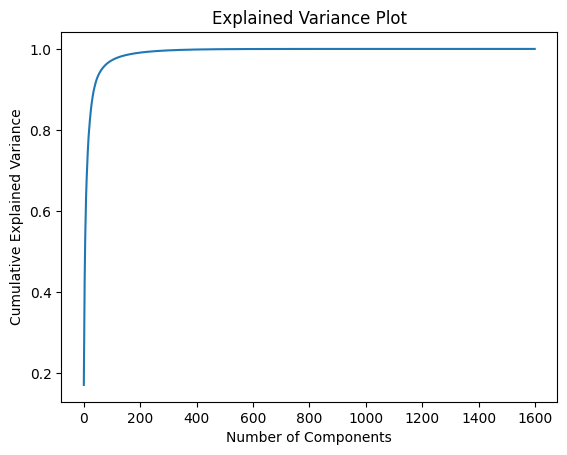

In [18]:
explained_variance = eigenvalues / np.sum(eigenvalues)
cumulative_variance = np.cumsum(explained_variance)

plt.plot(cumulative_variance)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance Plot")
plt.show()

3. Reconstruction and Experiment:

• Reconstruction: Transform the original data by multiplying it with the selected eigenvec-
tors(PCs) to obtain a lower-dimensional representation.

• Experiments: Pick Four different combination of principal components with various ex-
plained variance value and compare the result.

• Display the Results and Evaluate.

In [19]:
k = 50
PC = eigenvectors[:, :k]
compressed = np.dot(centered_data, PC)
reconstructed = np.dot(compressed, PC.T) + mean

In [20]:
pcs = [10,30,60,100]

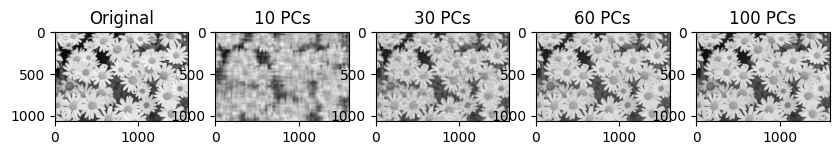

In [21]:
plt.figure(figsize=(10,6))

plt.subplot(1,5,1)
plt.imshow(img_array, cmap='gray')
plt.title("Original")

for i,k in enumerate(pcs):

    PC = eigenvectors[:,:k]
    compressed = np.dot(centered_data, PC)
    reconstructed = np.dot(compressed, PC.T) + mean

    plt.subplot(1,5,i+2)
    plt.imshow(reconstructed, cmap='gray')
    plt.title(f"{k} PCs")

plt.show()